
# Análise Financeira e Operacional

Este projeto analisa dados fictícios de faturamento, custos, metas e desempenho
operacional de quatro filiais ao longo de 2026.

## Objetivos

- Avaliar o desempenho financeiro das filiais;
- Comparar faturamento, custos e resultados;
- Verificar o atingimento das metas;
- Analisar a evolução mensal;
- Identificar os serviços com maior rentabilidade.

> Todos os dados utilizados são fictícios e destinados exclusivamente a fins educacionais e de portfólio.> Adicionar aspas



## 1. Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para manipulação, análise e visualização dos dados.

In [1]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from matplotlib.ticker import FuncFormatter
from pandas.api.types import is_numeric_dtype

sns.set_theme(style="whitegrid")

## 2. Carregamento da base de dados

A base de dados é carregada a partir de um arquivo CSV.

In [2]:
arquivos = files.upload()

nome_arquivo = list(arquivos.keys())[0]

df = pd.read_csv(
    io.BytesIO(arquivos[nome_arquivo]),
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo carregado:", nome_arquivo)

Saving base_financeira.csv to base_financeira (1).csv
Arquivo carregado: base_financeira (1).csv


In [3]:
df.head()

,Data,Mês,Filial,Tipo de serviço,Faturamento,Custo,Meta de faturamento,Quantidade de serviços,Prazo médio (dias),Resultado,Margem,Atingimento da meta,Ticket médio,Custo médio por serviço
0,15/01/2026,Janeiro,São Paulo,Manutenção preventiva,"R$ 35.000,00","R$ 22.000,00","R$ 32.000,00",12,8,"R$ 13.000,00","37,14%","109,38%","R$ 2.916,67","R$ 1.833,33"
1,15/01/2026,Janeiro,Rio de Janeiro,Manutenção corretiva,"R$ 29.800,00","R$ 21.100,00","R$ 31.000,00",8,12,"R$ 8.700,00","29,19%","96,13%","R$ 3.725,00","R$ 2.637,50"
2,15/01/2026,Janeiro,Belo Horizonte,Inspeção técnica,"R$ 22.400,00","R$ 13.700,00","R$ 23.000,00",10,6,"R$ 8.700,00","38,84%","97,39%","R$ 2.240,00","R$ 1.370,00"
3,15/01/2026,Janeiro,Salvador,Manutenção preventiva,"R$ 26.500,00","R$ 17.400,00","R$ 25.000,00",9,9,"R$ 9.100,00","34,34%","106,00%","R$ 2.944,44","R$ 1.933,33"
4,15/02/2026,Fevereiro,São Paulo,Manutenção corretiva,"R$ 38.200,00","R$ 24.900,00","R$ 35.000,00",11,11,"R$ 13.300,00","34,82%","109,14%","R$ 3.472,73","R$ 2.263,64"


## 3. Tratamento e preparação dos dados

Nesta etapa, os nomes das colunas são padronizados e os campos de data, valores monetários e percentuais são convertidos para os formatos adequados.

In [4]:
# Padronizar os nomes das colunas
df.columns = (
    df.columns
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Retirar espaços dos conteúdos de texto
for coluna in df.select_dtypes(include="object").columns:
    df[coluna] = df[coluna].str.strip()

# Converter a data
df["Data"] = pd.to_datetime(
    df["Data"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Converter valores monetários
colunas_monetarias = [
    "Faturamento",
    "Custo",
    "Meta de faturamento",
    "Resultado",
    "Ticket médio",
    "Custo médio por serviço"
]

for coluna in colunas_monetarias:
    if not is_numeric_dtype(df[coluna]):
        df[coluna] = (
            df[coluna]
            .str.replace("R$", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )

    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )

# Converter percentuais
colunas_percentuais = [
    "Margem",
    "Atingimento da meta"
]

for coluna in colunas_percentuais:
    if not is_numeric_dtype(df[coluna]):
        df[coluna] = (
            df[coluna]
            .str.replace("%", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )

        df[coluna] = (
            pd.to_numeric(df[coluna], errors="coerce") / 100
        )

print("Tratamento concluído.")

Tratamento concluído.


## 4. Validação da base

A base é verificada quanto à quantidade de registros, tipos de dados, valores ausentes e registros duplicados.

In [5]:
print("Linhas e colunas:", df.shape)

print("\nTipos das colunas:")
print(df.dtypes)

print("\nValores vazios:")
print(df.isnull().sum())

print("\nLinhas duplicadas:")
print(df.duplicated().sum())

Linhas e colunas: (48, 14)

Tipos das colunas:
Data                       datetime64[ns]
Mês                                object
Filial                             object
Tipo de serviço                    object
Faturamento                       float64
Custo                             float64
Meta de faturamento               float64
Quantidade de serviços              int64
Prazo médio (dias)                  int64
Resultado                         float64
Margem                            float64
Atingimento da meta               float64
Ticket médio                      float64
Custo médio por serviço           float64
dtype: object

Valores vazios:
Data                       0
Mês                        0
Filial                     0
Tipo de serviço            0
Faturamento                0
Custo                      0
Meta de faturamento        0
Quantidade de serviços     0
Prazo médio (dias)         0
Resultado                  0
Margem                     0
Atingimento da 

In [6]:
df.head()

,Data,Mês,Filial,Tipo de serviço,Faturamento,Custo,Meta de faturamento,Quantidade de serviços,Prazo médio (dias),Resultado,Margem,Atingimento da meta,Ticket médio,Custo médio por serviço
0,2026-01-15,Janeiro,São Paulo,Manutenção preventiva,35000.0,22000.0,32000.0,12,8,13000.0,0.3714,1.0938,2916.67,1833.33
1,2026-01-15,Janeiro,Rio de Janeiro,Manutenção corretiva,29800.0,21100.0,31000.0,8,12,8700.0,0.2919,0.9613,3725.00,2637.50
2,2026-01-15,Janeiro,Belo Horizonte,Inspeção técnica,22400.0,13700.0,23000.0,10,6,8700.0,0.3884,0.9739,2240.00,1370.00
3,2026-01-15,Janeiro,Salvador,Manutenção preventiva,26500.0,17400.0,25000.0,9,9,9100.0,0.3434,1.0600,2944.44,1933.33
4,2026-02-15,Fevereiro,São Paulo,Manutenção corretiva,38200.0,24900.0,35000.0,11,11,13300.0,0.3482,1.0914,3472.73,2263.64


## 5. Indicadores gerais

Nesta etapa, são calculados os principais indicadores financeiros e operacionais do período.

In [7]:
faturamento_total = df["Faturamento"].sum()
custo_total = df["Custo"].sum()
resultado_total = df["Resultado"].sum()
meta_total = df["Meta de faturamento"].sum()
quantidade_total = df["Quantidade de serviços"].sum()

margem_total = resultado_total / faturamento_total
atingimento_total = faturamento_total / meta_total
ticket_medio_total = faturamento_total / quantidade_total

print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Custo total: R$ {custo_total:,.2f}")
print(f"Resultado total: R$ {resultado_total:,.2f}")
print(f"Margem total: {margem_total:.2%}")
print(f"Meta atingida: {atingimento_total:.2%}")
print(f"Quantidade de serviços: {quantidade_total}")
print(f"Ticket médio: R$ {ticket_medio_total:,.2f}")

Faturamento total: R$ 1,677,000.00
Custo total: R$ 1,043,400.00
Resultado total: R$ 633,600.00
Margem total: 37.78%
Meta atingida: 101.64%
Quantidade de serviços: 584
Ticket médio: R$ 2,871.58


## 6. Análises financeiras e operacionais

### 6.1 Desempenho financeiro por filial

Esta análise compara faturamento, custo, resultado e margem entre as filiais.

In [8]:
resumo_filial = (
    df.groupby("Filial")[
        ["Faturamento", "Custo", "Resultado"]
    ]
    .sum()
    .sort_values("Faturamento", ascending=False)
)

resumo_filial["Margem"] = (
    resumo_filial["Resultado"] /
    resumo_filial["Faturamento"]
)

resumo_filial.style.format({
    "Faturamento": "R$ {:,.2f}",
    "Custo": "R$ {:,.2f}",
    "Resultado": "R$ {:,.2f}",
    "Margem": "{:.2%}"
})

,Faturamento,Custo,Resultado,Margem
Filial,,,,
São Paulo,"R$ 510,900.00","R$ 313,900.00","R$ 197,000.00",38.56%
Rio de Janeiro,"R$ 439,900.00","R$ 272,800.00","R$ 167,100.00",37.99%
Salvador,"R$ 367,900.00","R$ 232,200.00","R$ 135,700.00",36.89%
Belo Horizonte,"R$ 358,300.00","R$ 224,500.00","R$ 133,800.00",37.34%


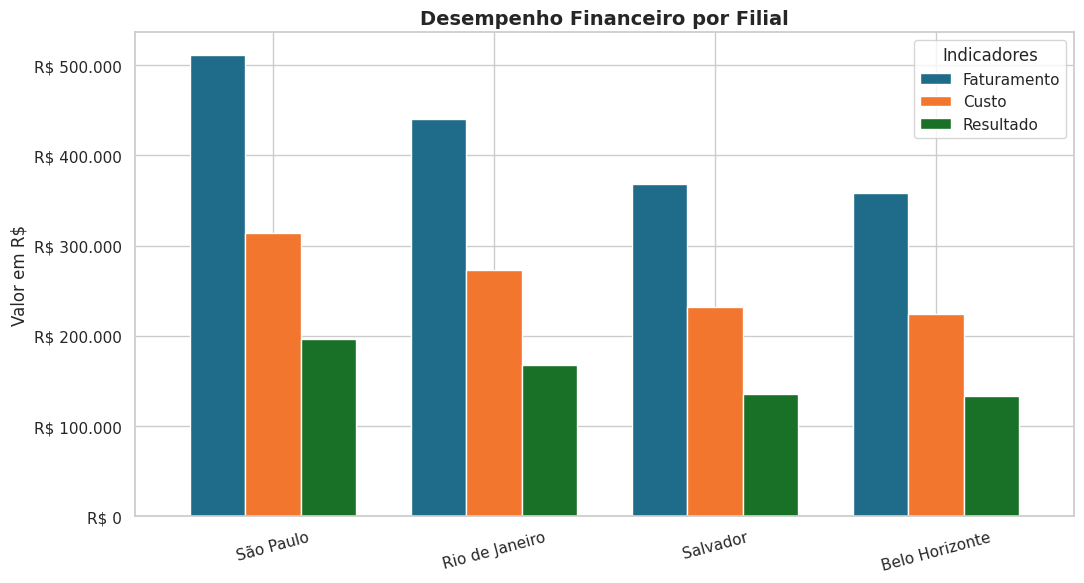

In [9]:
dados_filial = resumo_filial[
    ["Faturamento", "Custo", "Resultado"]
]

ax = dados_filial.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#1F6B8A", "#F2762E", "#197127"],
    width=0.75
)

ax.set_title(
    "Desempenho Financeiro por Filial",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Valor em R$")
ax.tick_params(axis="x", rotation=15)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao:
        f"R$ {valor:,.0f}".replace(",", ".")
    )
)

plt.legend(
    title="Indicadores",
    labels=["Faturamento", "Custo", "Resultado"]
)

plt.tight_layout()
plt.show()

### 6.2 Evolução mensal dos resultados

Esta análise apresenta o comportamento mensal do faturamento, custo e resultado.

In [10]:
resumo_mensal = (
    df.groupby(["Data", "Mês"])[
        ["Faturamento", "Custo", "Resultado"]
    ]
    .sum()
    .reset_index()
    .sort_values("Data")
)

resumo_mensal

,Data,Mês,Faturamento,Custo,Resultado
0,2026-01-15,Janeiro,113700.0,74200.0,39500.0
1,2026-02-15,Fevereiro,118200.0,76300.0,41900.0
2,2026-03-15,Março,118700.0,73800.0,44900.0
3,2026-04-15,Abril,130500.0,82700.0,47800.0
4,2026-05-15,Maio,132400.0,86500.0,45900.0
5,2026-06-15,Junho,136200.0,83500.0,52700.0
6,2026-07-15,Julho,144200.0,89300.0,54900.0
7,2026-08-15,Agosto,145400.0,93400.0,52000.0
8,2026-09-15,Setembro,149800.0,89200.0,60600.0
9,2026-10-15,Outubro,159600.0,96000.0,63600.0


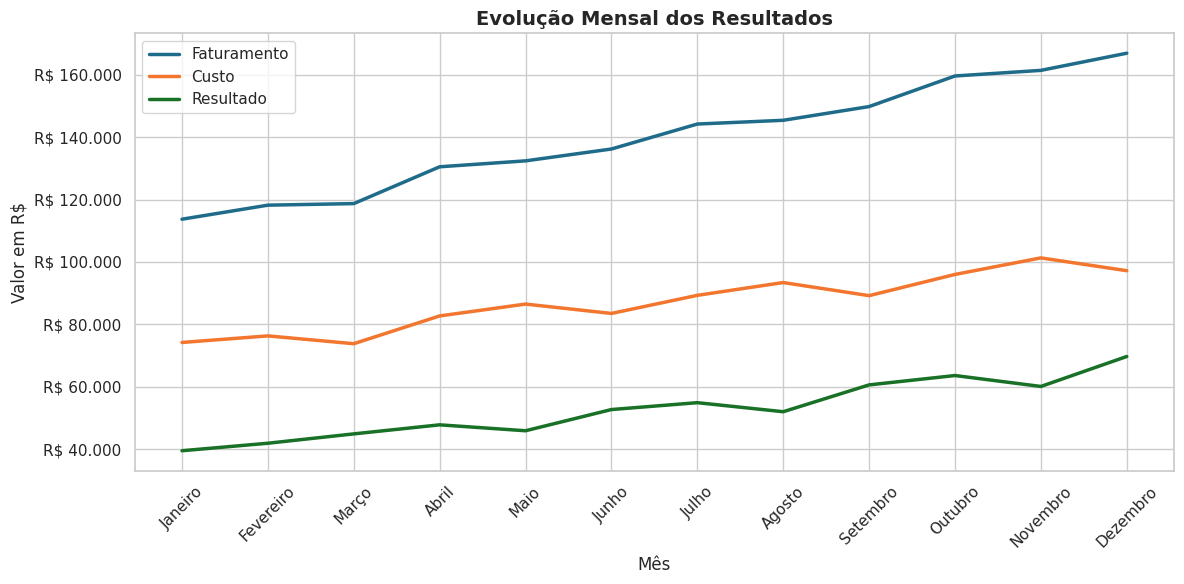

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    resumo_mensal["Mês"],
    resumo_mensal["Faturamento"],
    linewidth=2.5,
    color="#1F6B8A",
    label="Faturamento"
)

plt.plot(
    resumo_mensal["Mês"],
    resumo_mensal["Custo"],
    linewidth=2.5,
    color="#F2762E",
    label="Custo"
)

plt.plot(
    resumo_mensal["Mês"],
    resumo_mensal["Resultado"],
    linewidth=2.5,
    color="#197127",
    label="Resultado"
)

plt.title(
    "Evolução Mensal dos Resultados",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mês")
plt.ylabel("Valor em R$")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao:
        f"R$ {valor:,.0f}".replace(",", ".")
    )
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Rentabilidade por tipo de serviço

Esta análise compara faturamento, custo, resultado e margem dos tipos de serviço.

In [12]:
resumo_servico = (
    df.groupby("Tipo de serviço")[
        ["Faturamento", "Custo", "Resultado"]
    ]
    .sum()
)

resumo_servico["Margem"] = (
    resumo_servico["Resultado"] /
    resumo_servico["Faturamento"]
)

resumo_servico = resumo_servico.sort_values(
    "Margem",
    ascending=False
)

resumo_servico.style.format({
    "Faturamento": "R$ {:,.2f}",
    "Custo": "R$ {:,.2f}",
    "Resultado": "R$ {:,.2f}",
    "Margem": "{:.2%}"
})

,Faturamento,Custo,Resultado,Margem
Tipo de serviço,,,,
Inspeção técnica,"R$ 550,100.00","R$ 314,600.00","R$ 235,500.00",42.81%
Manutenção preventiva,"R$ 564,900.00","R$ 341,000.00","R$ 223,900.00",39.64%
Manutenção corretiva,"R$ 562,000.00","R$ 387,800.00","R$ 174,200.00",31.00%


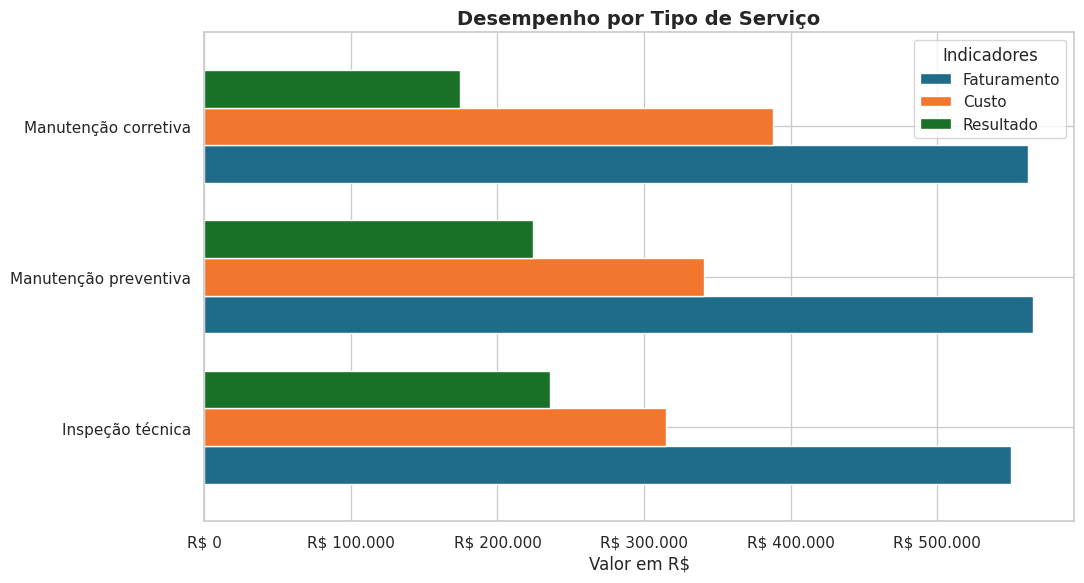

In [13]:
dados_servico = resumo_servico[
    ["Faturamento", "Custo", "Resultado"]
]

ax = dados_servico.plot(
    kind="barh",
    figsize=(11, 6),
    color=["#1F6B8A", "#F2762E", "#197127"],
    width=0.75
)

ax.set_title(
    "Desempenho por Tipo de Serviço",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Valor em R$")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao:
        f"R$ {valor:,.0f}".replace(",", ".")
    )
)

plt.legend(
    title="Indicadores",
    labels=["Faturamento", "Custo", "Resultado"]
)

plt.tight_layout()
plt.show()

### 6.4 Faturamento versus meta por filial

Esta análise compara o faturamento realizado com a meta planejada de cada filial.

In [14]:
resumo_meta = (
    df.groupby("Filial")[
        ["Faturamento", "Meta de faturamento"]
    ]
    .sum()
)

resumo_meta["Atingimento"] = (
    resumo_meta["Faturamento"] /
    resumo_meta["Meta de faturamento"]
)

resumo_meta["Status"] = resumo_meta["Atingimento"].apply(
    lambda percentual:
    "Meta atingida"
    if percentual >= 1
    else "Abaixo da meta"
)

resumo_meta = resumo_meta.sort_values(
    "Atingimento",
    ascending=False
)

resumo_meta.style.format({
    "Faturamento": "R$ {:,.2f}",
    "Meta de faturamento": "R$ {:,.2f}",
    "Atingimento": "{:.2%}"
})

,Faturamento,Meta de faturamento,Atingimento,Status
Filial,,,,
São Paulo,"R$ 510,900.00","R$ 498,000.00",102.59%,Meta atingida
Rio de Janeiro,"R$ 439,900.00","R$ 429,000.00",102.54%,Meta atingida
Salvador,"R$ 367,900.00","R$ 365,000.00",100.79%,Meta atingida
Belo Horizonte,"R$ 358,300.00","R$ 358,000.00",100.08%,Meta atingida


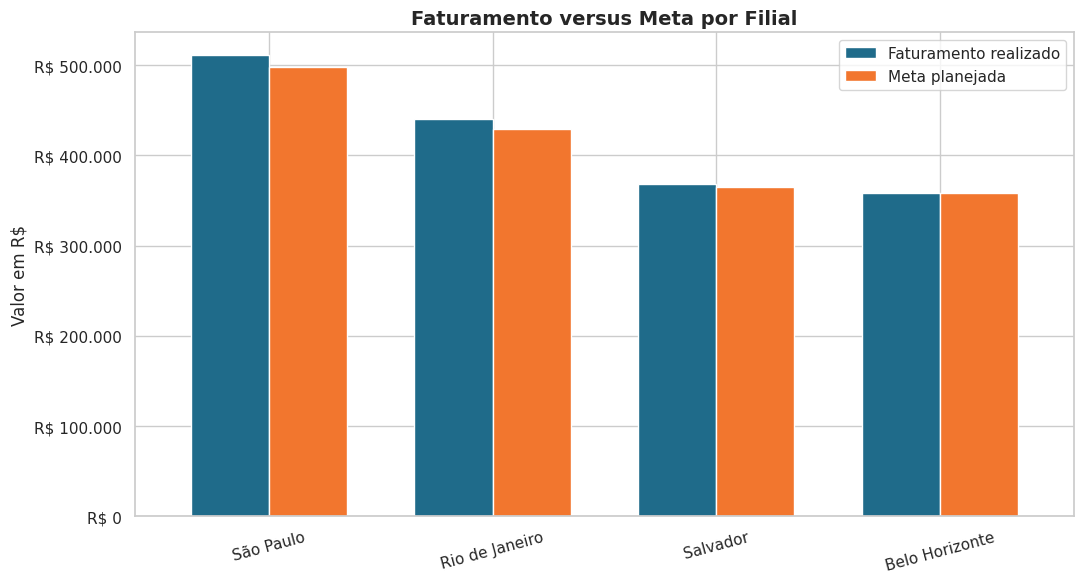

In [15]:
ax = resumo_meta[
    ["Faturamento", "Meta de faturamento"]
].plot(
    kind="bar",
    figsize=(11, 6),
    color=["#1F6B8A", "#F2762E"],
    width=0.7
)

ax.set_title(
    "Faturamento versus Meta por Filial",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Valor em R$")
ax.tick_params(axis="x", rotation=15)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao:
        f"R$ {valor:,.0f}".replace(",", ".")
    )
)

plt.legend(
    labels=["Faturamento realizado", "Meta planejada"]
)

plt.tight_layout()
plt.show()

## 7. Dashboard financeiro e operacional

Os indicadores e gráficos anteriores são reunidos em uma visualização consolidada.

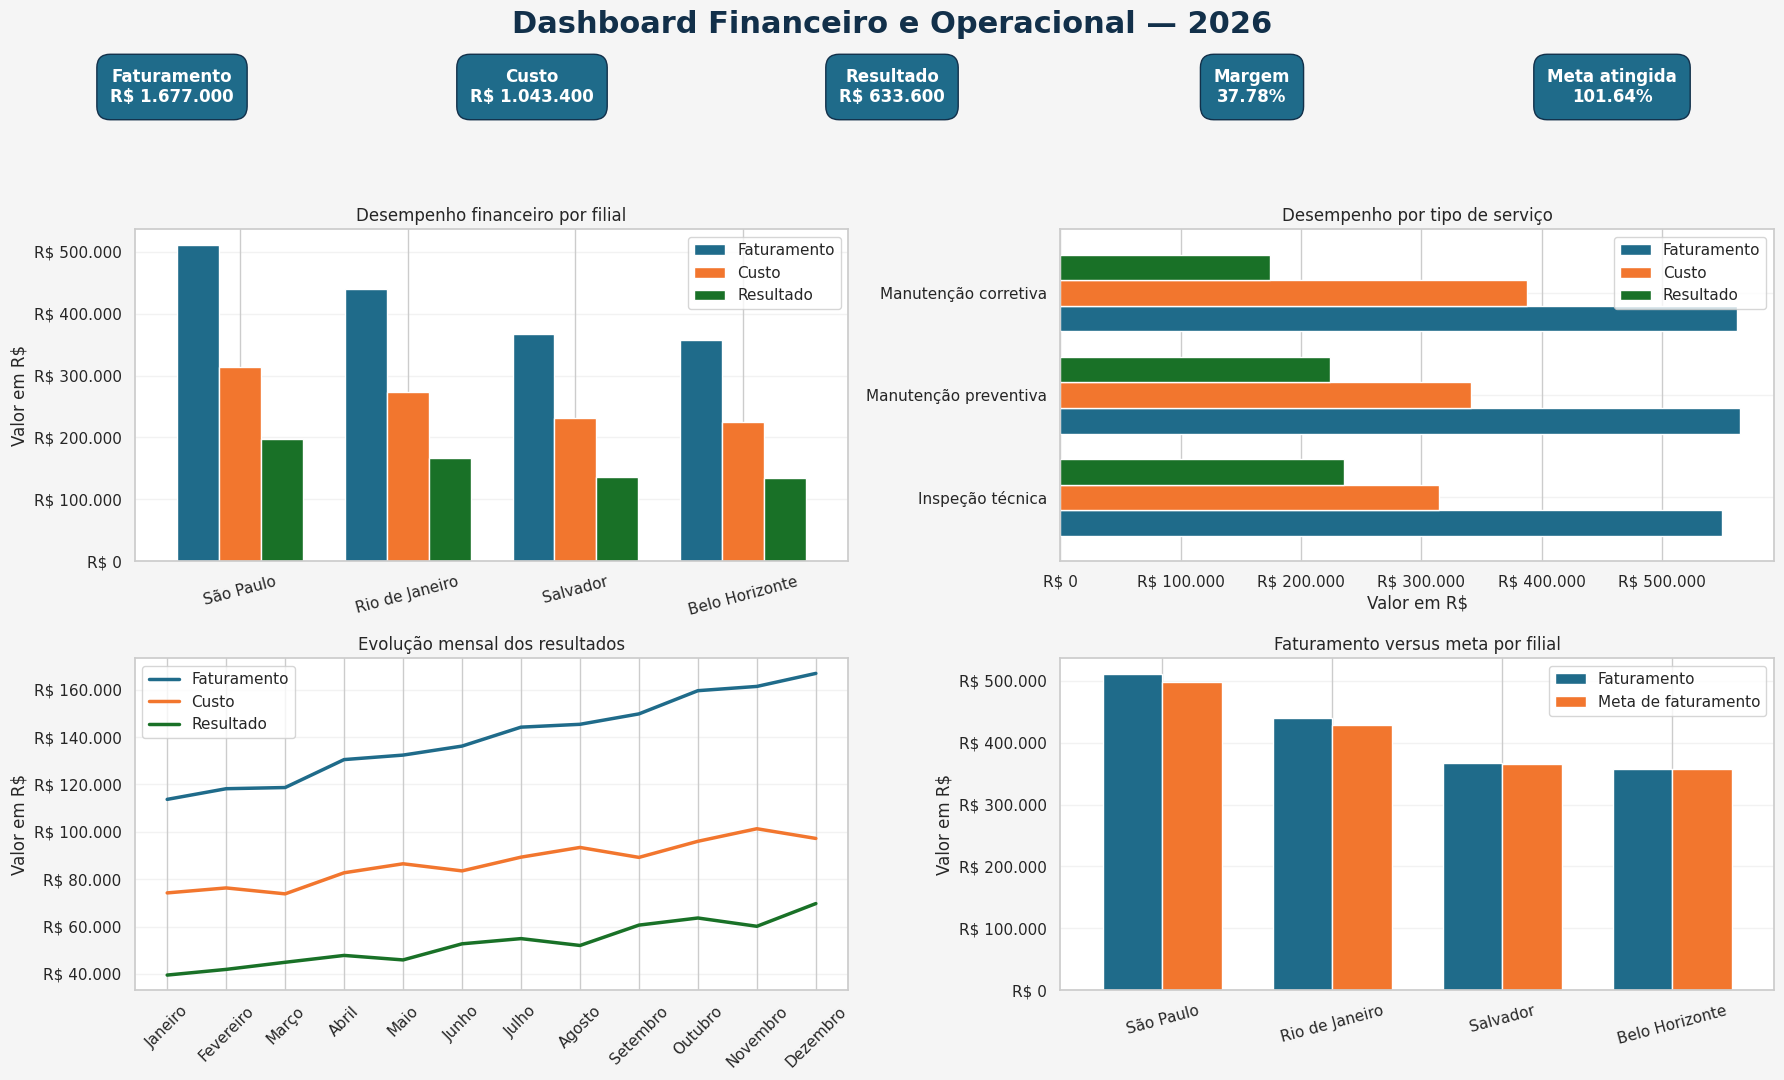

In [16]:
# Indicadores gerais
faturamento_total = df["Faturamento"].sum()
custo_total = df["Custo"].sum()
resultado_total = df["Resultado"].sum()
meta_total = df["Meta de faturamento"].sum()

margem_total = resultado_total / faturamento_total
atingimento_total = faturamento_total / meta_total

# Formatação dos eixos em reais
formato_reais = FuncFormatter(
    lambda valor, posicao:
    f"R$ {valor:,.0f}".replace(",", ".")
)

# Criar a estrutura do dashboard
fig, eixos = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

fig.patch.set_facecolor("#F5F5F5")

fig.suptitle(
    "Dashboard Financeiro e Operacional — 2026",
    fontsize=22,
    fontweight="bold",
    color="#12304A",
    y=0.98
)

# Indicadores apresentados no topo
indicadores = [
    ("Faturamento", f"R$ {faturamento_total:,.0f}"),
    ("Custo", f"R$ {custo_total:,.0f}"),
    ("Resultado", f"R$ {resultado_total:,.0f}"),
    ("Margem", f"{margem_total:.2%}"),
    ("Meta atingida", f"{atingimento_total:.2%}")
]

posicoes = [0.10, 0.30, 0.50, 0.70, 0.90]

for posicao, (titulo, valor) in zip(posicoes, indicadores):
    valor = valor.replace(",", ".")

    fig.text(
        posicao,
        0.91,
        f"{titulo}\n{valor}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
        bbox={
            "boxstyle": "round,pad=0.8",
            "facecolor": "#1F6B8A",
            "edgecolor": "#12304A"
        }
    )

# 1. Desempenho financeiro por filial
resumo_filial[
    ["Faturamento", "Custo", "Resultado"]
].plot(
    kind="bar",
    ax=eixos[0, 0],
    color=["#1F6B8A", "#F2762E", "#197127"],
    width=0.75
)

eixos[0, 0].set_title("Desempenho financeiro por filial")
eixos[0, 0].set_xlabel("")
eixos[0, 0].set_ylabel("Valor em R$")
eixos[0, 0].tick_params(axis="x", rotation=15)
eixos[0, 0].yaxis.set_major_formatter(formato_reais)

# 2. Desempenho por tipo de serviço
resumo_servico[
    ["Faturamento", "Custo", "Resultado"]
].plot(
    kind="barh",
    ax=eixos[0, 1],
    color=["#1F6B8A", "#F2762E", "#197127"],
    width=0.75
)

eixos[0, 1].set_title("Desempenho por tipo de serviço")
eixos[0, 1].set_xlabel("Valor em R$")
eixos[0, 1].set_ylabel("")
eixos[0, 1].xaxis.set_major_formatter(formato_reais)

# 3. Evolução mensal
eixos[1, 0].plot(
    resumo_mensal["Mês"],
    resumo_mensal["Faturamento"],
    color="#1F6B8A",
    linewidth=2.5,
    label="Faturamento"
)

eixos[1, 0].plot(
    resumo_mensal["Mês"],
    resumo_mensal["Custo"],
    color="#F2762E",
    linewidth=2.5,
    label="Custo"
)

eixos[1, 0].plot(
    resumo_mensal["Mês"],
    resumo_mensal["Resultado"],
    color="#197127",
    linewidth=2.5,
    label="Resultado"
)

eixos[1, 0].set_title("Evolução mensal dos resultados")
eixos[1, 0].set_xlabel("")
eixos[1, 0].set_ylabel("Valor em R$")
eixos[1, 0].tick_params(axis="x", rotation=45)
eixos[1, 0].yaxis.set_major_formatter(formato_reais)
eixos[1, 0].legend()

# 4. Faturamento versus meta por filial
resumo_meta[
    ["Faturamento", "Meta de faturamento"]
].plot(
    kind="bar",
    ax=eixos[1, 1],
    color=["#1F6B8A", "#F2762E"],
    width=0.7
)

eixos[1, 1].set_title("Faturamento versus meta por filial")
eixos[1, 1].set_xlabel("")
eixos[1, 1].set_ylabel("Valor em R$")
eixos[1, 1].tick_params(axis="x", rotation=15)
eixos[1, 1].yaxis.set_major_formatter(formato_reais)

# Padronizar todos os gráficos
for eixo in eixos.flat:
    eixo.grid(axis="y", alpha=0.25)
    eixo.set_facecolor("white")

# Ajustar espaço para título e indicadores
plt.tight_layout(
    rect=[0, 0, 1, 0.86]
)

# Salvar o dashboard como imagem
plt.savefig(
    "dashboard_financeiro_python.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
files.download("dashboard_financeiro_python.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Principais conclusões

- O faturamento total foi de R$ 1.677.000,00.
- O custo total foi de R$ 1.043.400,00.
- O resultado acumulado foi de R$ 633.600,00.
- A margem consolidada foi de 37,78%.
- O faturamento superou a meta geral em 1,64%.
- São Paulo apresentou o maior faturamento e o maior resultado.
- A inspeção técnica apresentou a maior margem percentual.
- A manutenção corretiva apresentou a menor margem entre os serviços analisados.
- Os resultados demonstraram crescimento ao longo do ano, apesar de algumas oscilações mensais.

## Tecnologias utilizadas

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

## Autora

Camile Ribeiro Silva

Engenheira Aeronáutica com experiência em Controladoria Operacional e interesse em Análise de Dados, Business Intelligence e Finanças.